RQ1 (DNN): Can introducing semantically valid, artificially crafted, and maliciously altered network flow perturbations, creating the effects of a network poisoning attack, into an IDS training dataset, such as the Unified Multimodal NIDS CIC-IDS2019 dataset, reduce the robustness of the training of the model?

H10: Using bootstrap resampling to estimate precision, recall, and FPR with 95% confidence intervals, introducing perturbations to the model's training dataset has no statistically significant effect on the model's overall performance.

H1a: Using bootstrap resampling to estimate precision, recall, and FPR with 95% confidence intervals, introducing perturbations to the model's training dataset has a statistically significant effect on the model's overall performance.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils import resample
from torch.utils.data import DataLoader, TensorDataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cpu


In [2]:
df_sample = pd.read_csv('clean_sample_150000.csv')

In [3]:
le = LabelEncoder()
df_sample['label'] = le.fit_transform(df_sample['label'])
X = df_sample.drop(columns=['label'], errors='ignore').select_dtypes(include=[np.number])
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(0, inplace=True)
y = df_sample['label']
label_mapping = dict(zip(le.classes_, range(len(le.classes_))))
print(label_mapping)

{'BENIGN': 0, 'DoS_ATTACK': 1, 'NON_DoS_ATTACK': 2}


In [4]:
X_train_df, X_test_df, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train_df = X_train_df.reset_index(drop=True)
X_test_df  = X_test_df.reset_index(drop=True)
y_train    = y_train.reset_index(drop=True)
y_test     = y_test.reset_index(drop=True).to_numpy()

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_df).astype(np.float32)
X_test_sc  = scaler.transform(X_test_df).astype(np.float32)

X_test_tensor = torch.tensor(X_test_sc, dtype=torch.float32)

In [5]:
INPUT_SIZE = X_train_sc.shape[1]

class MultiClassDNN(nn.Module):
    def __init__(self, input_size=INPUT_SIZE, num_classes=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, num_classes)
        )
    def forward(self, x):
        return self.net(x)

def train_dnn(X_tr_sc, y_tr_arr, epochs=50, lr=0.001, batch_size=2048):
    m = MultiClassDNN(input_size=X_tr_sc.shape[1]).to(device)
    opt = torch.optim.Adam(m.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
    ds = TensorDataset(
        torch.tensor(X_tr_sc, dtype=torch.float32),
        torch.tensor(y_tr_arr, dtype=torch.long)
    )
    loader = DataLoader(ds, batch_size=batch_size, shuffle=True)
    m.train()
    for _ in range(epochs):
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            loss = criterion(m(xb), yb)
            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(m.parameters(), 1.0)
            opt.step()
    return m

def dnn_predict(m, X_sc):
    m.eval()
    with torch.no_grad():
        logits = m(torch.tensor(X_sc, dtype=torch.float32).to(device))
        return logits.argmax(dim=1).cpu().numpy()

def dnn_predict_proba(m, X_sc):
    m.eval()
    with torch.no_grad():
        logits = m(torch.tensor(X_sc, dtype=torch.float32).to(device))
        return torch.softmax(logits, dim=1).cpu().numpy()

In [6]:
model = train_dnn(X_train_sc, y_train.to_numpy(), epochs=50)
torch.save(model.state_dict(), 'multiclass_dnn_rq1.pth')
print('Baseline DNN trained and saved.')

Baseline DNN trained and saved.


In [7]:
y_pred = dnn_predict(model, X_test_sc)
y_prob = dnn_predict_proba(model, X_test_sc)
print('Accuracy:', accuracy_score(y_test, y_pred))
print('Weighted F1:', f1_score(y_test, y_pred, average='weighted'))
print('Macro F1:', f1_score(y_test, y_pred, average='macro'))
print('ROC-AUC:', roc_auc_score(y_test, y_prob, multi_class='ovr', average='weighted'))

Accuracy: 0.8901333333333333
Weighted F1: 0.8900567797535
Macro F1: 0.8900567797534998
ROC-AUC: 0.9726776


In [8]:
print(classification_report(y_test, y_pred, target_names=le.classes_))

                precision    recall  f1-score   support

        BENIGN       1.00      1.00      1.00     10000
    DoS_ATTACK       0.83      0.85      0.84     10000
NON_DoS_ATTACK       0.85      0.82      0.83     10000

      accuracy                           0.89     30000
     macro avg       0.89      0.89      0.89     30000
  weighted avg       0.89      0.89      0.89     30000



In [9]:
proba_train = dnn_predict_proba(model, X_train_sc)
y_train_arr = y_train.to_numpy()

attack_mask = y_train_arr != 0
atk_idx = np.where(attack_mask)[0]
atk_X_df = X_train_df.iloc[atk_idx].reset_index(drop=True)
atk_y = y_train_arr[atk_idx]
atk_proba = proba_train[atk_idx]

true_class_conf = atk_proba[np.arange(len(atk_y)), atk_y]
order = np.argsort(true_class_conf)
boundary_X_df = atk_X_df.iloc[order].reset_index(drop=True)
boundary_y_arr = atk_y[order]
boundary_conf = true_class_conf[order]

boundary_df = boundary_X_df.copy()
boundary_df['true_label'] = boundary_y_arr
boundary_df['confidence'] = boundary_conf
boundary_df.to_csv('boundary_attacks.csv', index=False)

print(f'Saved {len(boundary_df)} boundary-adjacent attack samples')
print(f'Confidence range: {boundary_conf.min():.4f} – {boundary_conf.max():.4f}')
print(f'Bottom 10% confidence threshold: {np.percentile(boundary_conf, 10):.4f}')

Saved 80000 boundary-adjacent attack samples
Confidence range: 0.0219 – 0.9930
Bottom 10% confidence threshold: 0.3297


In [10]:
noise_df = pd.read_csv('noise_epsilon_0.2.csv')
noise_X = noise_df.drop(columns=['true_label', 'y_pred'], errors='ignore').select_dtypes(include=[np.number])
noise_X.replace([np.inf, -np.inf], np.nan, inplace=True)
noise_X.fillna(0, inplace=True)
noise_y = noise_df['true_label'].reset_index(drop=True).values
noise_X = noise_X.astype('float32')

noise_pred = dnn_predict(model, scaler.transform(noise_X))
print('Accuracy:', accuracy_score(noise_y, noise_pred))
print('Weighted F1:', f1_score(noise_y, noise_pred, average='weighted'))
print('Macro F1:', f1_score(noise_y, noise_pred, average='macro'))

Accuracy: 0.9275457912628748
Weighted F1: 0.9339379974723475
Macro F1: 0.8132174815477056


In [11]:
adv_df = pd.read_csv('adversarial_epsilon_0.2.csv')
adv_X = adv_df.drop(columns=['true_label', 'pred_clean', 'pred_adv'], errors='ignore').select_dtypes(include=[np.number])
adv_X.replace([np.inf, -np.inf], np.nan, inplace=True)
adv_X.fillna(0, inplace=True)
adv_y = adv_df['true_label'].reset_index(drop=True).values
adv_X = adv_X.astype('float32')

adv_pred = dnn_predict(model, scaler.transform(adv_X))
print('Accuracy:', accuracy_score(adv_y, adv_pred))
print('Weighted F1:', f1_score(adv_y, adv_pred, average='weighted'))
print('Macro F1:', f1_score(adv_y, adv_pred, average='macro'))

Accuracy: 0.3404255319148936
Weighted F1: 0.3231912669840901
Macro F1: 0.3231912669840901


In [12]:
hsj_df = pd.read_csv('adversarial_hsj_xgb.csv')
hsj_X = hsj_df.drop(columns=['true_label', 'pred_clean', 'pred_adv'], errors='ignore').select_dtypes(include=[np.number])
hsj_X.replace([np.inf, -np.inf], np.nan, inplace=True)
hsj_X.fillna(0, inplace=True)
hsj_y = hsj_df['true_label'].reset_index(drop=True).values
hsj_X = hsj_X.astype('float32')

hsj_pred = dnn_predict(model, scaler.transform(hsj_X))
print('Accuracy:', accuracy_score(hsj_y, hsj_pred))
print('Weighted F1:', f1_score(hsj_y, hsj_pred, average='weighted'))
print('Macro F1:', f1_score(hsj_y, hsj_pred, average='macro'))

Accuracy: 0.6053811659192825
Weighted F1: 0.7541899441340782
Macro F1: 0.25139664804469275


In [13]:
boundary_df = pd.read_csv('boundary_attacks.csv')
boundary_X = boundary_df.drop(columns=['true_label', 'confidence'], errors='ignore').select_dtypes(include=[np.number])
boundary_X.replace([np.inf, -np.inf], np.nan, inplace=True)
boundary_X.fillna(0, inplace=True)
boundary_y = boundary_df['true_label'].reset_index(drop=True).values
boundary_X = boundary_X.astype('float32')
print(f'Boundary samples: {len(boundary_df)}, class distribution: {dict(zip(*np.unique(boundary_y, return_counts=True)))}')

Boundary samples: 80000, class distribution: {np.int64(1): np.int64(40000), np.int64(2): np.int64(40000)}


Running t-SNE on 2188 samples (scaled feature space)...


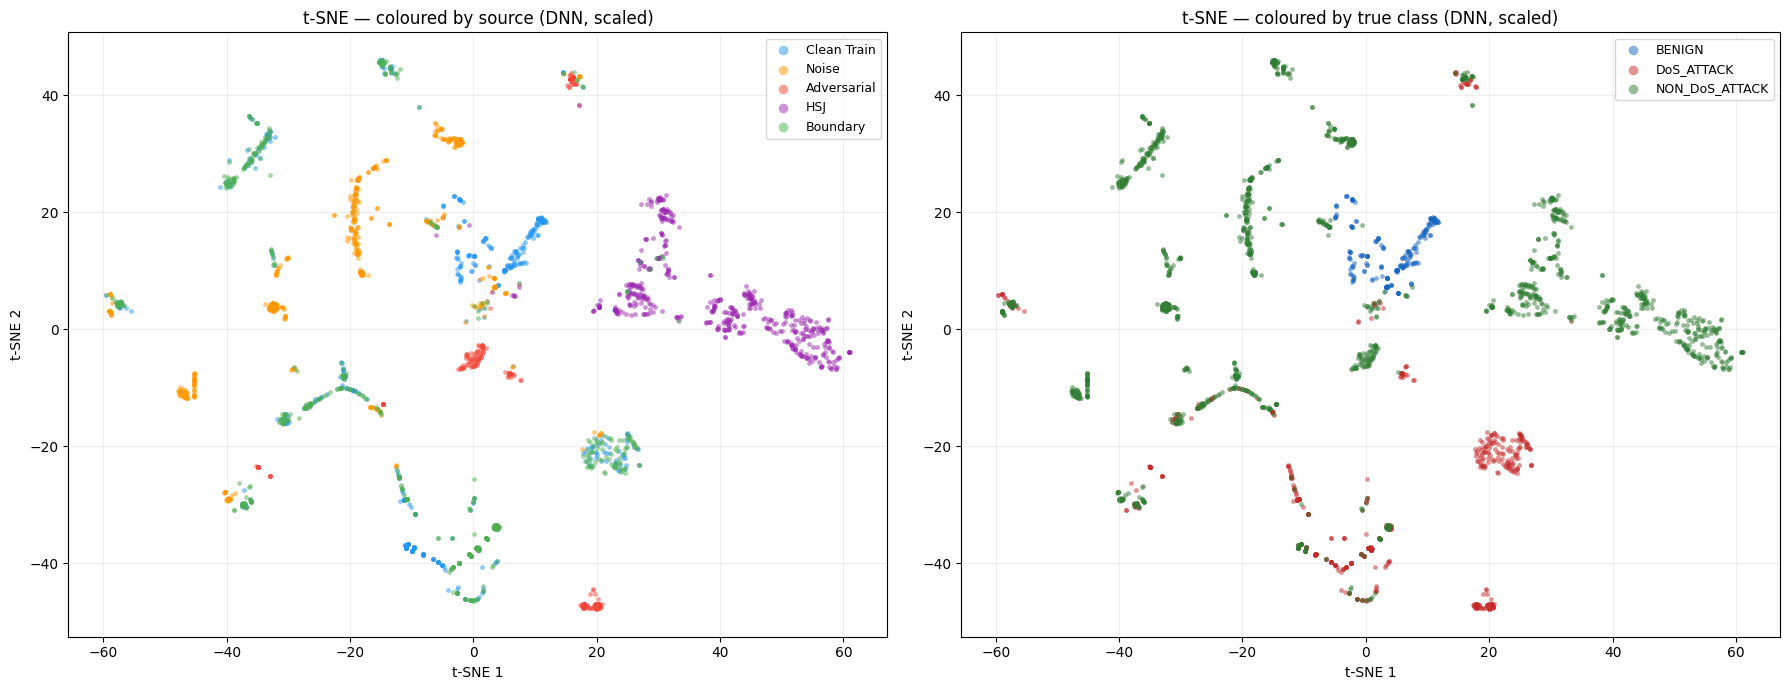

Saved tsne_dnn.png


In [14]:
from sklearn.manifold import TSNE

N_TSNE = 500
rng_tsne = np.random.default_rng(42)

cols = X_train_df.columns.tolist()

sources_tsne = {
    "Clean Train": (X_train_sc,                          y_train.to_numpy()),
    "Noise":       (scaler.transform(noise_X[cols]),      noise_y),
    "Adversarial": (scaler.transform(adv_X[cols]),        adv_y),
    "HSJ":         (scaler.transform(hsj_X[cols]),        hsj_y),
    "Boundary":    (scaler.transform(boundary_X[cols]),   boundary_y),
}

all_X_tsne, all_source, all_class = [], [], []
for src_name, (sx, sy) in sources_tsne.items():
    n = min(N_TSNE, len(sx))
    idx = rng_tsne.choice(len(sx), size=n, replace=False)
    all_X_tsne.append(sx[idx])
    all_source.extend([src_name] * n)
    all_class.extend(sy[idx].tolist())

all_X_tsne = np.vstack(all_X_tsne).astype(np.float32)
all_source  = np.array(all_source)
all_class   = np.array(all_class)

print(f"Running t-SNE on {len(all_X_tsne)} samples (scaled feature space)...")
tsne = TSNE(n_components=2, perplexity=40, max_iter=1000, random_state=42, n_jobs=-1)
Z = tsne.fit_transform(all_X_tsne)

src_order  = ["Clean Train", "Noise", "Adversarial", "HSJ", "Boundary"]
src_colors = {"Clean Train": "#2196F3", "Noise": "#FF9800", "Adversarial": "#F44336",
              "HSJ": "#9C27B0", "Boundary": "#4CAF50"}
cls_colors = {0: "#1565C0", 1: "#C62828", 2: "#2E7D32"}
cls_labels = {i: c for i, c in enumerate(le.classes_)}

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

ax = axes[0]
for src in src_order:
    mask = all_source == src
    ax.scatter(Z[mask, 0], Z[mask, 1], c=src_colors[src], label=src,
               alpha=0.5, s=12, linewidths=0)
ax.set_title("t-SNE — coloured by source (DNN, scaled)")
ax.set_xlabel("t-SNE 1"); ax.set_ylabel("t-SNE 2")
ax.legend(markerscale=2, fontsize=9); ax.grid(True, alpha=0.2)

ax = axes[1]
for cls in [0, 1, 2]:
    mask = all_class == cls
    ax.scatter(Z[mask, 0], Z[mask, 1], c=cls_colors[cls],
               label=cls_labels[cls], alpha=0.5, s=12, linewidths=0)
ax.set_title("t-SNE — coloured by true class (DNN, scaled)")
ax.set_xlabel("t-SNE 1"); ax.set_ylabel("t-SNE 2")
ax.legend(markerscale=2, fontsize=9); ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig("tsne_dnn.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved tsne_dnn.png")

In [15]:
def poison_training_set(X_train_df, y_train_s, ae_X, ae_y, poison_rate, random_state=42):
    ae_X = ae_X[X_train_df.columns] if hasattr(ae_X, 'columns') else ae_X
    if hasattr(ae_X, 'reset_index'):
        ae_X = ae_X.reset_index(drop=True)
    rng = np.random.default_rng(random_state)
    n_total = len(X_train_df)
    n_poison = int(n_total * poison_rate)
    X_clean = X_train_df.reset_index(drop=True).copy()
    y_clean = y_train_s.reset_index(drop=True).to_numpy().copy() if hasattr(y_train_s, 'reset_index') else y_train_s.copy()
    if n_poison == 0:
        shuffle_idx = rng.permutation(n_total)
        return X_clean.iloc[shuffle_idx].reset_index(drop=True), y_clean[shuffle_idx]
    attack_mask = ae_y != 0
    ae_X_attacks = ae_X[attack_mask].reset_index(drop=True) if hasattr(ae_X, 'reset_index') else pd.DataFrame(ae_X[attack_mask], columns=X_train_df.columns)
    ae_y_attacks = ae_y[attack_mask]
    chosen = rng.choice(len(ae_X_attacks), size=n_poison, replace=(n_poison > len(ae_X_attacks)))
    X_poison = ae_X_attacks.iloc[chosen].reset_index(drop=True).copy()
    y_poison = np.zeros(n_poison, dtype=int)
    keep_mask = np.ones(n_total, dtype=bool)
    train_classes = np.unique(y_clean)
    class_train_counts = np.array([np.sum(y_clean == c) for c in train_classes])
    class_train_fracs = class_train_counts / n_total
    drop_per_class = np.floor(class_train_fracs * n_poison).astype(int)
    drop_remainder = n_poison - drop_per_class.sum()
    drop_order = np.argsort(-class_train_fracs)
    for i in range(drop_remainder):
        drop_per_class[drop_order[i % len(train_classes)]] += 1
    for i, cls in enumerate(train_classes):
        cls_idx = np.where(y_clean == cls)[0]
        n_drop = min(drop_per_class[i], len(cls_idx))
        to_drop = rng.choice(cls_idx, size=n_drop, replace=False)
        keep_mask[to_drop] = False
    keep_idx = np.where(keep_mask)[0]
    n_keep = n_total - n_poison
    if len(keep_idx) > n_keep:
        excess = len(keep_idx) - n_keep
        trim_mask = np.ones(len(keep_idx), dtype=bool)
        kept_classes, kept_counts = np.unique(y_clean[keep_idx], return_counts=True)
        kept_fracs = kept_counts / kept_counts.sum()
        trim_per_class = np.floor(kept_fracs * excess).astype(int)
        trim_rem = excess - trim_per_class.sum()
        trim_order = np.argsort(-kept_fracs)
        for j in range(trim_rem):
            trim_per_class[trim_order[j % len(kept_classes)]] += 1
        for j, cls in enumerate(kept_classes):
            cls_positions = np.where(y_clean[keep_idx] == cls)[0]
            to_trim = rng.choice(cls_positions, size=trim_per_class[j], replace=False)
            trim_mask[to_trim] = False
        keep_idx = keep_idx[trim_mask]
    elif len(keep_idx) < n_keep:
        extra_pool = np.where(~keep_mask)[0]
        extra = rng.choice(extra_pool, size=n_keep - len(keep_idx), replace=False)
        keep_idx = np.concatenate([keep_idx, extra])
    X_kept = X_clean.iloc[keep_idx].reset_index(drop=True)
    y_kept = y_clean[keep_idx]
    X_poisoned = pd.concat([X_kept, X_poison], ignore_index=True)
    y_poisoned = np.concatenate([y_kept, y_poison])
    shuffle_idx = rng.permutation(len(X_poisoned))
    return X_poisoned.iloc[shuffle_idx].reset_index(drop=True), y_poisoned[shuffle_idx]

In [16]:
def fpr_benign(y_true, y_pred):
    labels = np.unique(y_true)
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    benign_idx = np.where(labels == 0)[0][0]
    fp = cm[:, benign_idx].sum() - cm[benign_idx, benign_idx]
    n_non_benign = cm.sum() - cm[benign_idx].sum()
    tn = n_non_benign - fp
    return fp / (fp + tn + 1e-10)

In [17]:
GROUPS = {
    'Control (0%)':       0.00,
    'Experiment 1 (5%)':  0.05,
    'Experiment 2 (10%)': 0.10,
    'Experiment 3 (15%)': 0.15,
    'Experiment 4 (20%)': 0.20,
    'Experiment 5 (25%)': 0.25,
    'Experiment 6 (30%)': 0.30,
    'Experiment 7 (35%)': 0.35,
    'Experiment 8 (40%)': 0.40,
    'Experiment 9 (45%)': 0.45,
    'Experiment 10 (50%)': 0.50,
}

N_BOOTSTRAPS = 500

In [ ]:
all_results = {'Noise': [], 'Adversarial': [], 'HSJ': [], 'Boundary': []}
group_preds = {'Noise': {}, 'Adversarial': {}, 'HSJ': {}, 'Boundary': {}}

sources = [
    ('Noise',       noise_X,    noise_y),
    ('Adversarial', adv_X,      adv_y),
    ('HSJ',         hsj_X,      hsj_y),
    ('Boundary',    boundary_X, boundary_y),
]

for source_name, ae_X, ae_y in sources:
    # Convert ae_X to DataFrame with matching columns for poison_training_set
    ae_X_df = pd.DataFrame(ae_X.values if hasattr(ae_X, 'values') else ae_X, columns=X_train_df.columns[:ae_X.shape[1]])
    for group_name, poison_rate in GROUPS.items():
        X_tr_df, y_tr = poison_training_set(X_train_df, y_train, ae_X_df, ae_y, poison_rate)
        X_tr_sc = scaler.transform(X_tr_df).astype(np.float32)
        exp_model = train_dnn(X_tr_sc, y_tr, epochs=30)
        y_pred = dnn_predict(exp_model, X_test_sc)
        bootstrap_indices = [resample(np.arange(len(y_test)), replace=True) for _ in range(N_BOOTSTRAPS)]
        group_preds[source_name][group_name] = y_pred
        acc  = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
        rec  = recall_score(y_test, y_pred, average='macro', zero_division=0)
        mac  = f1_score(y_test, y_pred, average='macro', zero_division=0)
        wt   = f1_score(y_test, y_pred, average='weighted', zero_division=0)
        fpr  = fpr_benign(y_test, y_pred)
        acc_b, prec_b, rec_b, mac_b, wt_b, fpr_b = [], [], [], [], [], []
        for idx in bootstrap_indices:
            acc_b.append(accuracy_score(y_test[idx], y_pred[idx]))
            prec_b.append(precision_score(y_test[idx], y_pred[idx], average='macro', zero_division=0))
            rec_b.append(recall_score(y_test[idx], y_pred[idx], average='macro', zero_division=0))
            mac_b.append(f1_score(y_test[idx], y_pred[idx], average='macro', zero_division=0))
            wt_b.append(f1_score(y_test[idx], y_pred[idx], average='weighted', zero_division=0))
            fpr_b.append(fpr_benign(y_test[idx], y_pred[idx]))
        def ci(vals): return np.percentile(vals, 2.5), np.percentile(vals, 97.5)
        all_results[source_name].append({
            'Group': group_name,
            'Poison Rate': poison_rate,
            'Accuracy': round(acc, 4),        'Acc CI': ci(acc_b),
            'Macro Precision': round(prec, 4), 'Prec CI': ci(prec_b),
            'Macro Recall': round(rec, 4),     'Rec CI': ci(rec_b),
            'Macro F1': round(mac, 4),         'MacF1 CI': ci(mac_b),
            'Weighted F1': round(wt, 4),       'WtF1 CI': ci(wt_b),
            'Benign FPR': round(fpr, 4),       'FPR CI': ci(fpr_b),
        })
        print(f'[{source_name}] {group_name}: Acc={acc:.4f} Rec={rec:.4f} F1={mac:.4f}')

In [ ]:
for source_name, results in all_results.items():
    print(f'\n\n══ {source_name.upper()} — SUMMARY WITH 95% BOOTSTRAP CIs ══')
    summary = pd.DataFrame([{
        'Group': r['Group'],
        'Poison Rate': f"{int(r['Poison Rate']*100)}%",
        'Accuracy': f"{r['Accuracy']} [{r['Acc CI'][0]:.4f}, {r['Acc CI'][1]:.4f}]",
        'Macro Precision': f"{r['Macro Precision']} [{r['Prec CI'][0]:.4f}, {r['Prec CI'][1]:.4f}]",
        'Macro Recall': f"{r['Macro Recall']} [{r['Rec CI'][0]:.4f}, {r['Rec CI'][1]:.4f}]",
        'Macro F1': f"{r['Macro F1']} [{r['MacF1 CI'][0]:.4f}, {r['MacF1 CI'][1]:.4f}]",
        'Weighted F1': f"{r['Weighted F1']} [{r['WtF1 CI'][0]:.4f}, {r['WtF1 CI'][1]:.4f}]",
    } for r in results])
    display(summary)

    print(f'\n══ {source_name.upper()} — BOOTSTRAP p-VALUES vs CONTROL ══')
    ctrl_pred = group_preds[source_name]['Control (0%)']
    hyp_results = []
    for group_name, poison_rate in GROUPS.items():
        if poison_rate == 0.0:
            continue
        exp_pred = group_preds[source_name][group_name]
        diffs = []
        for _ in range(N_BOOTSTRAPS):
            idx = resample(np.arange(len(y_test)), replace=True)
            diffs.append(f1_score(y_test[idx], ctrl_pred[idx], average='macro', zero_division=0) -
                         f1_score(y_test[idx], exp_pred[idx], average='macro', zero_division=0))
        diffs = np.array(diffs)
        p = min(np.mean(diffs <= 0), np.mean(diffs >= 0)) * 2
        hyp_results.append({
            'Comparison': f'Control vs {group_name}',
            'Mean F1 Drop': round(np.mean(diffs), 4),
            '95% CI': f'[{np.percentile(diffs,2.5):.4f}, {np.percentile(diffs,97.5):.4f}]',
            'p-value': round(p, 6),
            'Significant': 'Yes' if p < 0.05 else 'No',
        })
    display(pd.DataFrame(hyp_results))

In [ ]:
class_names = le.classes_
poison_labels = [f"{int(v*100)}%" for v in GROUPS.values()]

fig, axes = plt.subplots(1, 4, figsize=(22, 5), sharey=True)
fig.suptitle('Per-Class Recall vs Poison Rate (DNN)', fontsize=14)

for ax, source_name in zip(axes, ['Noise', 'Adversarial', 'HSJ', 'Boundary']):
    per_class_recall = {c: [] for c in class_names}
    for group_name in GROUPS:
        y_pred = group_preds[source_name][group_name]
        for i, cls in enumerate(class_names):
            mask = y_test == i
            per_class_recall[cls].append(np.mean(y_pred[mask] == i) if mask.sum() > 0 else np.nan)
    for cls in class_names:
        ax.plot(poison_labels, per_class_recall[cls], marker='o', label=cls)
    ax.set_title(source_name)
    ax.set_xlabel('Poison Rate')
    ax.set_ylabel('Recall')
    ax.set_ylim(0, 1.05)
    ax.legend()
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

for source_name in ['Noise', 'Adversarial', 'HSJ', 'Boundary']:
    print(f'\n══ {source_name.upper()} — PER-CLASS RECALL ══')
    rows = []
    for group_name, poison_rate in GROUPS.items():
        y_pred = group_preds[source_name][group_name]
        row = {'Group': group_name, 'Poison Rate': f"{int(poison_rate*100)}%"}
        for i, cls in enumerate(class_names):
            mask = y_test == i
            row[f'Recall ({cls})'] = round(np.mean(y_pred[mask] == i), 4) if mask.sum() > 0 else np.nan
        rows.append(row)
    display(pd.DataFrame(rows))